In [1]:
# %load_ext autoreload
# %autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import skopi as sk

import torch
from tqdm import tqdm 
import time
import h5py

from neurorient import uniform_points_on_sphere
from neurorient.reconstruction.slicing import get_reciprocal_mesh, get_real_mesh

import os, glob
os.environ["USE_CUPY"] = "1"
os.environ.get('USE_CUPY')

/pscratch/sd/z/zhantao/conda/inr/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


'1'

In [2]:
data_type = '7K_iUCrJ'

In [3]:
data_path = "/pscratch/sd/z/zhantao/neurorient_repo/data_PR772"
save_dir = '/pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use'

In [4]:
h5_file = '/pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/amo86615_PR772_7k_PCA_7303.h5'

with h5py.File(h5_file, "r") as f:
    images = f['photonConverter/pnccdBack/photonCount'][:]
images = images[:,1:-2,:]

In [5]:
print(images.shape)

(7303, 257, 257)


In [6]:
det = np.loadtxt('input/dragonfly/det_pnccd_back.dat', skiprows=1)
det_shape = (260, 257)

In [7]:
pixel_position_reciprocal = 1e7 * det[:,:3].reshape((1,)+det_shape+(3,))
pixel_position_reciprocal = pixel_position_reciprocal[:,1:-2,:,:]

In [9]:
pixel_position_reciprocal.shape

(1, 257, 257, 3)

In [10]:
img_real_mesh = get_real_mesh(min(det_shape), pixel_position_reciprocal.max())
_mesh = get_reciprocal_mesh(min(det_shape), pixel_position_reciprocal.max())
vol_real_mesh = get_real_mesh(_mesh.shape[0], _mesh.max())

In [9]:
idx_xx, idx_yy = np.meshgrid(np.arange(min(det_shape)), np.arange(min(det_shape)))

In [10]:
pixel_index_map = np.concatenate([idx_xx[None,...,None], idx_yy[None,...,None]], axis=-1)

In [23]:
pt_fpath = os.path.join(save_dir, f'PR772_neurorient_{data_type}.pt')
torch.save(
    {
        'orientations': None,
        'intensities': torch.from_numpy(images.astype('float')).float(),
        'pixel_position_reciprocal': torch.from_numpy(pixel_position_reciprocal).float(),
        'pixel_index_map': torch.from_numpy(pixel_index_map).long(),
        'volume': None,
        'img_real_mesh': img_real_mesh.float(),
        'vol_real_mesh': vol_real_mesh.float(),
        'time_stamp': time.strftime("%Y%m%d-%H%M")
    }, pt_fpath
)
print("data wrote to: \n", pt_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ.pt


In [32]:
N = images.shape[0]  # Define the range N
odd_indices_mask = torch.zeros(N, dtype=torch.float32)
odd_indices_mask[1::2] = 1  # Set mask for odd indices

even_indices_mask = torch.zeros(N, dtype=torch.float32)
even_indices_mask[::2] = 1  # Set mask for even indices

print(odd_indices_mask)
print(even_indices_mask)

tensor([0., 1., 0.,  ..., 0., 1., 0.])
tensor([1., 0., 1.,  ..., 1., 0., 1.])


In [36]:
pt_fpath = os.path.join(save_dir, f'PR772_neurorient_{data_type}_oddHalf.pt')
torch.save(
    {
        'orientations': None,
        'intensities': torch.from_numpy(images.astype('float')).float()[odd_indices_mask.bool()],
        'pixel_position_reciprocal': torch.from_numpy(pixel_position_reciprocal).float(),
        'pixel_index_map': torch.from_numpy(pixel_index_map).long(),
        'volume': None,
        'img_real_mesh': img_real_mesh.float(),
        'vol_real_mesh': vol_real_mesh.float(),
        'time_stamp': time.strftime("%Y%m%d-%H%M")
    }, pt_fpath
)
print("data wrote to: \n", pt_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ_oddHalf.pt


In [38]:
pt_fpath = os.path.join(save_dir, f'PR772_neurorient_{data_type}_evenHalf.pt')
torch.save(
    {
        'orientations': None,
        'intensities': torch.from_numpy(images.astype('float')).float()[even_indices_mask.bool()],
        'pixel_position_reciprocal': torch.from_numpy(pixel_position_reciprocal).float(),
        'pixel_index_map': torch.from_numpy(pixel_index_map).long(),
        'volume': None,
        'img_real_mesh': img_real_mesh.float(),
        'vol_real_mesh': vol_real_mesh.float(),
        'time_stamp': time.strftime("%Y%m%d-%H%M")
    }, pt_fpath
)
print("data wrote to: \n", pt_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ_evenHalf.pt


In [1]:
from pytorch3d.transforms import random_rotations

In [3]:
random_rotations(1).shape

torch.Size([1, 3, 3])

In [18]:
pixel_distance_reciprocal = np.linalg.norm(pixel_position_reciprocal, axis=-1)

In [19]:
h5_fpath = os.path.join(
    save_dir, 
    f'PR772_neurorient_{data_type}.h5')
with h5py.File(h5_fpath, 'w') as f:
    f.create_dataset('intensities', data=images[:1000, None])
    f.create_dataset('orientations', data=np.zeros((images.shape[0], 4)))
    f.create_dataset('pixel_position_reciprocal', data=pixel_position_reciprocal)
    f.create_dataset('pixel_distance_reciprocal', data=pixel_distance_reciprocal)
    f.create_dataset('pixel_index_map', data=pixel_index_map)
print("data wrote to: \n", h5_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_.h5


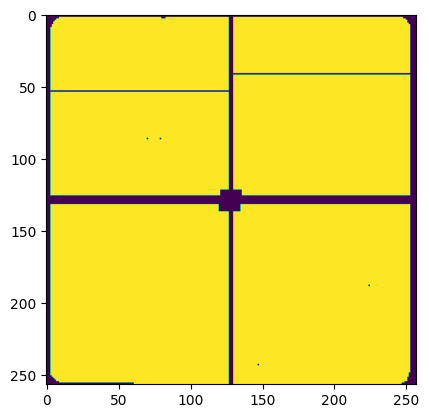

In [20]:
_beam_stop_mask = det[:,-1].reshape(det_shape)[1:-2,:]
beam_stop_mask = torch.zeros(_beam_stop_mask.shape)
beam_stop_mask[_beam_stop_mask!=2] = 1
plt.imshow(beam_stop_mask)
torch.save({'mask': beam_stop_mask.float()}, 'input/PR772/beam_stop_mask.pt')